## Python Assignment :
1. Create a NumPy array of 50 random numbers and find the 2nd largest
and 3rd smallest element.

In [1]:
import numpy as np
np.random.seed(42)
arr = np.random.rand(50)
arr.sort()
print("2nd largest number is ",arr[-2])
print("3rd smallest number is ",arr[2])

2nd largest number is  0.9656320330745594
3rd smallest number is  0.046450412719997725


2. Given a DataFrame, identify all columns having more than 20% missing
values and remove them.

In [32]:
! pip install pandas
import pandas as pd
data = {
    "A": [1, 2, np.nan, 4, 5],  
    "B": [1, np.nan, np.nan, 4, 5], 
    "C": [1, 2, 3, 4, 5], 
    "D": [np.nan, np.nan, 3, np.nan, 5], 
}
df = pd.DataFrame(data)
columns_to_drop = [col for col in df.columns if df[col].isnull().mean() > 0.20]
df_cleaned = df.drop(columns = columns_to_drop)
print("Dropped columns:", columns_to_drop)

Dropped columns: ['B', 'D']


3. Create a NumPy matrix and find its transpose, determinant, rank, and
inverse.

In [51]:
import numpy as np
matrix = np.array([[2,1,3],[0,5,6],[1,2,3]])
print("Original Matrix:")
print(matrix)
transpose_matrix = matrix.T
print("Transpose:")
print(transpose_matrix)
det_value = np.linalg.det(matrix)
print(f"Determinant:{det_value:.2f}")
matrix_rank = np.linalg.matrix_rank(matrix)
print(f"Rank: {matrix_rank}")

try:
    inverse_matrix = np.linalg.inv(matrix)
    print(f"Inverse:\n{inverse_matrix}")
except np.linalg.LinAlgError:
    print("Inverse")
    print("Matrix is singular and cannot be inverted")

Original Matrix:
[[2 1 3]
 [0 5 6]
 [1 2 3]]
Transpose:
[[2 0 1]
 [1 5 2]
 [3 6 3]]
Determinant:-3.00
Rank: 3
Inverse:
[[-1.         -1.          3.        ]
 [-2.         -1.          4.        ]
 [ 1.66666667  1.         -3.33333333]]


4. Using Pandas, find the top 5 categories with the highest average value
of a numerical column.

In [53]:
import pandas as pd
data = {'Category':['Electronics','Clothing','Electronics','Home','Clothing','Home','Books','Books'
                    ,'Toys','Toys','Sports','Sports'],
        'Value' : [200,40,150,300,60,250,20,30,15,25,500,450]}

df = pd.DataFrame(data)

top_5_categories = df.groupby('Category')['Value'].mean().sort_values(ascending = False).head()
print("Top 5 categories by highest average value")
print(top_5_categories)

Top 5 categories by highest average value
Category
Sports         475.0
Home           275.0
Electronics    175.0
Clothing        50.0
Books           25.0
Name: Value, dtype: float64


5. Create a Seaborn heatmap and identify the three most highly
correlated feature pairs.

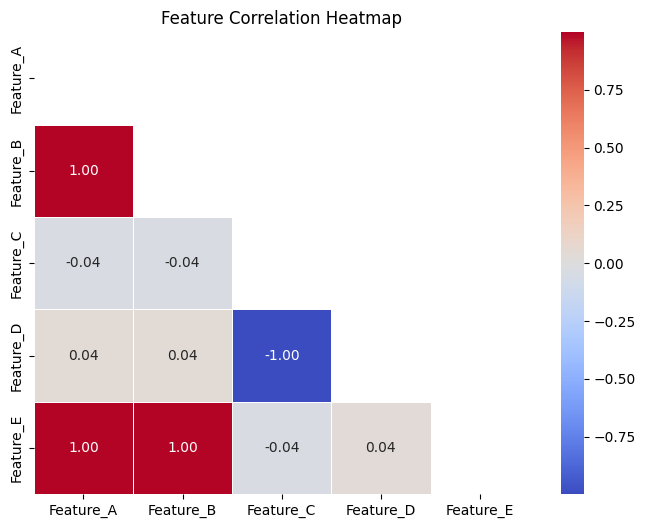

--- Top 3 Most Highly Correlated Feature Pairs ---
Feature_D and Feature_C -> Correlation: -0.9989
Feature_C and Feature_D -> Correlation: -0.9989
Feature_B and Feature_A -> Correlation: 0.9986


In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
data = {'Feature_A':np.random.rand(100),
        'Feature_B':np.random.rand(100),
        'Feature_C':np.random.rand(100),
        'Feature_D':np.random.rand(100),
        'Feature_E':np.random.rand(100),}

df = pd.DataFrame(data)

df['Feature_B'] = df['Feature_A'] * 0.95 + np.random.rand(100) * 0.05
df['Feature_D'] = df['Feature_C'] * -0.95 + np.random.rand(100) * 0.05
df['Feature_E'] = df['Feature_A'] * 0.85 + np.random.rand(100) * 0.05

corr_matrix = df.corr()
plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
corr_pairs = corr_matrix.abs().unstack()
filtered_pairs = corr_pairs[corr_pairs < 1.0]
unique_pairs = filtered_pairs.iloc[::2]
top_3_pairs = unique_pairs.sort_values(ascending=False).head(3)

print("--- Top 3 Most Highly Correlated Feature Pairs ---")
for (f1, f2), val in top_3_pairs.items():
    original_val = corr_matrix.loc[f1, f2]
    print(f"{f1} and {f2} -> Correlation: {original_val:.4f}")

6. Generate a dataset with NumPy and visualize its distribution using
Histogram, KDE Plot, and Box Plot.

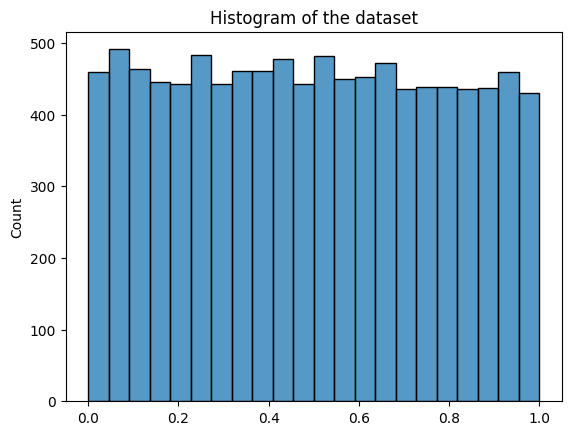

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = np.random.rand(10000)
sns.histplot(data)
plt.title("Histogram of the dataset")
plt.show()

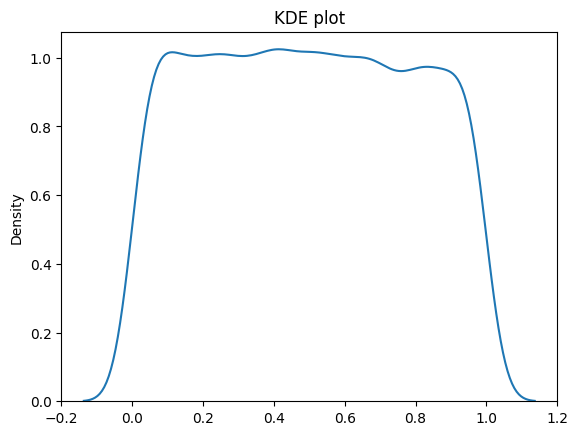

In [5]:
sns.kdeplot(data)
plt.title("KDE plot")
plt.show()

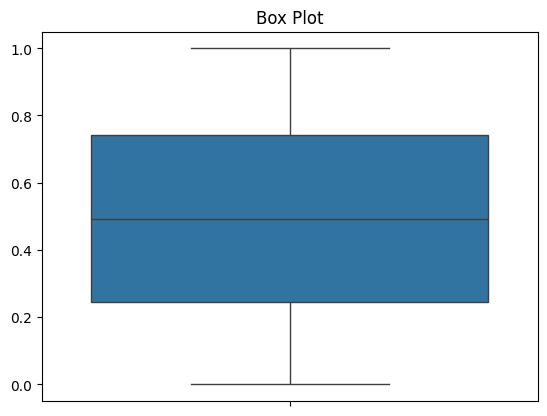

In [6]:
sns.boxplot(data)
plt.title("Box Plot")
plt.show()

7. Using Pandas GroupBy, find the highest, lowest, and average sales for
each category.

In [58]:
import pandas as pd
data = {
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 
                 'Home', 'Books', 'Books', 'Toys', 'Toys', 'Sports', 'Sports'],
    'Sales': [1200.50, 45.00, 850.00, 320.00, 65.00, 290.00, 15.99, 24.50, 12.00, 42.50, 510.00, 490.00]
}
df = pd.DataFrame(data)
sales_summary = df.groupby('Category')['Sales'].agg(['max', 'min', 'mean']).round(2)
sales_summary.columns = ['Highest_Sales', 'Lowest_Sales', 'Average_Sales']

print("Sales Metrics Summary Per Category")
print(sales_summary)


Sales Metrics Summary Per Category
             Highest_Sales  Lowest_Sales  Average_Sales
Category                                               
Books                 24.5         15.99          20.24
Clothing              65.0         45.00          55.00
Electronics         1200.5        850.00        1025.25
Home                 320.0        290.00         305.00
Sports               510.0        490.00         500.00
Toys                  42.5         12.00          27.25


8. Detect outliers in a numerical column using the IQR method and
visualize them using a Box Plot.

IQR Boundaries 
Lower Bound: 27.26 | Upper Bound: 71.86

Detected Outliers (6 found)
     Engine_Output
100       5.000000
101      12.000000
74       23.802549
102      95.000000
103     102.000000
104     110.000000


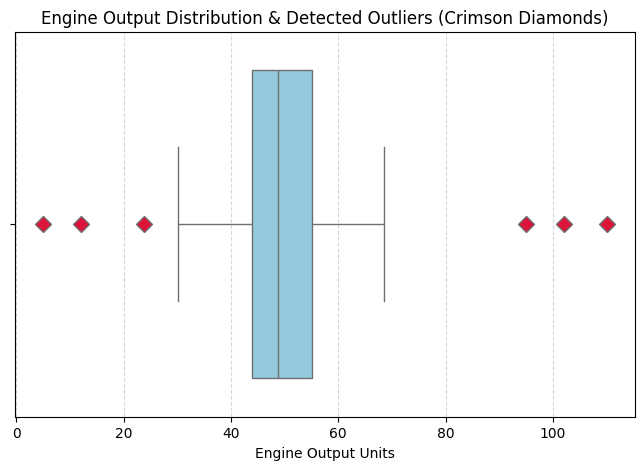

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
normal_data = np.random.normal(loc=50, scale=10, size=100) 
outliers = np.array([5, 12, 95, 102, 110])                
all_data = np.concatenate([normal_data, outliers])

df = pd.DataFrame({'Engine_Output': all_data})

Q1 = df['Engine_Output'].quantile(0.25)
Q3 = df['Engine_Output'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_df = df[(df['Engine_Output'] < lower_bound) | (df['Engine_Output'] > upper_bound)]

print(f"IQR Boundaries ")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}\n")
print(f"Detected Outliers ({len(outliers_df)} found)")
print(outliers_df.sort_values(by='Engine_Output').to_string(index=True))

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df['Engine_Output'], 
    color='skyblue', 
    flierprops={"markerfacecolor": "crimson", "marker": "D", "markersize": 8}
)

plt.title("Engine Output Distribution & Detected Outliers (Crimson Diamonds)")
plt.xlabel("Engine Output Units")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


9. Create a Matplotlib figure containing 4 subplots:
o Line Plot
o Bar Plot
o Scatter Plot
o Histogram

(array([  9.,  13.,  66., 164., 280., 237., 156.,  61.,  10.,   4.]),
 array([-3.37557910e+00, -2.70024437e+00, -2.02490963e+00, -1.34957490e+00,
        -6.74240164e-01,  1.09457056e-03,  6.76429305e-01,  1.35176404e+00,
         2.02709877e+00,  2.70243351e+00,  3.37776824e+00]),
 <BarContainer object of 10 artists>)

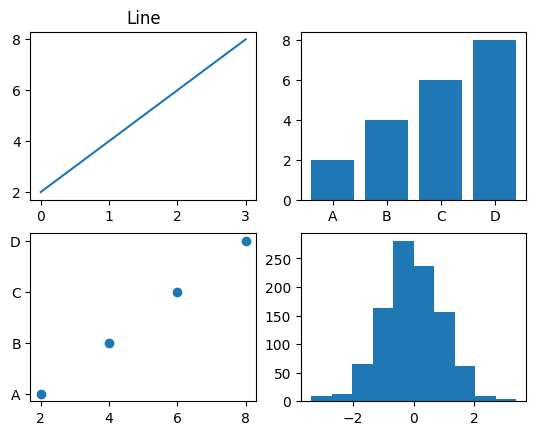

In [22]:
import matplotlib.pyplot as plt

data_x = [2,4,6,8]
data_y = ['A','B','C','D']
hist_data = np.random.randn(1000)

plt.subplot(2,2,1)
plt.plot(data_x)
plt.title("Line")
plt.subplot(2,2,2)
plt.bar(x = data_y , height =data_x)
plt.subplot(2,2,3)
plt.scatter(data_x,data_y)
plt.subplot(2,2,4)
plt.hist(hist_data)

10. Create a rolling average of window size 7 on a dataset and compare
it with the original trend using Matplotlib.

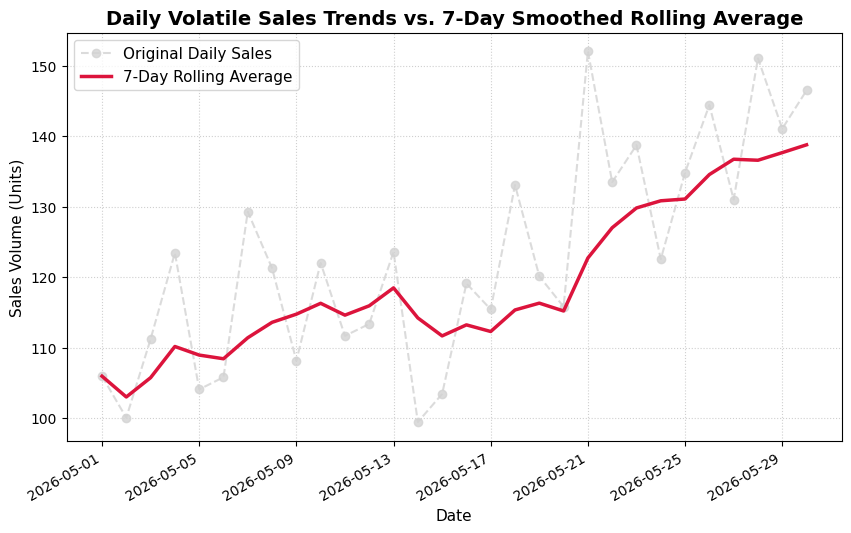

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
date_range = pd.date_range(start="2026-05-01", periods=30, freq="D")
base_trend = np.linspace(100, 150, 30) 
noise = np.random.normal(loc=0, scale=12, size=30)  
daily_sales = base_trend + noise

df = pd.DataFrame({"Date": date_range, "Daily_Sales": daily_sales})
df.set_index("Date", inplace=True)


df["7_Day_Rolling_Avg"] = df["Daily_Sales"].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(10, 6))

plt.plot(
    df.index,
    df["Daily_Sales"],
    label="Original Daily Sales",
    color="lightgray",
    linestyle="--",
    marker="o",
    alpha=0.8,
)

plt.plot(
    df.index,
    df["7_Day_Rolling_Avg"],
    label="7-Day Rolling Average",
    color="crimson",
    linewidth=2.5,
)

plt.title(
    "Daily Volatile Sales Trends vs. 7-Day Smoothed Rolling Average",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Sales Volume (Units)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.gcf().autofmt_xdate()  
plt.legend(fontsize=11, loc="upper left")

plt.show()


11. Using Seaborn, compare two numerical features using:
● Scatter Plot
● Pair Plot
● Joint Plot

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


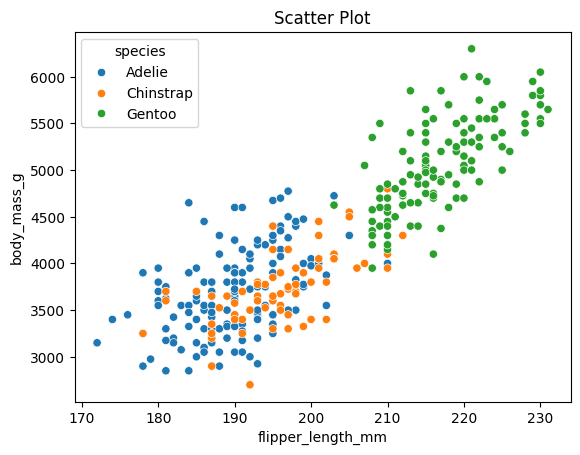

In [29]:
sns.scatterplot(x = "flipper_length_mm" , y = "body_mass_g",data = df , hue = "species")
plt.title("Scatter Plot")
plt.show()

12. Build a mini EDA report that includes:
● Missing Values Analysis
● Correlation Analysis
● Outlier Detection
● Feature Distribution Visualization

 STARTING MINI EDA REPORT EXECUTION 

MISSING VALUES ANALYSIS
           Missing_Count  Percentage_%
Feature_A              0           0.0
Feature_B             10           5.0
Feature_C              6           3.0
Target                 0           0.0

--------------------------------------------------

 CORRELATION ANALYSIS
Correlation Matrix Coefficients (Pearson):
           Feature_A  Feature_B  Feature_C  Target
Feature_A       1.00      -0.06      -0.06    0.44
Feature_B      -0.06       1.00       0.06   -0.00
Feature_C      -0.06       0.06       1.00   -0.00
Target          0.44      -0.00      -0.00    1.00

--------------------------------------------------

[3/4] OUTLIER DETECTION (IQR METHOD)
Column 'Feature_A': Bounds [24.5 to 73.8] -> Outliers Found: 6
Column 'Feature_B': Bounds [-29.9 to 142.1] -> Outliers Found: 0
Column 'Feature_C': Bounds [15.9 to 43.4] -> Outliers Found: 1
Column 'Target': Bounds [33.6 to 114.1] -> Outliers Found: 2

---------------------------

C:\Users\user\AppData\Local\Temp\ipykernel_20596\829283775.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_report.index, y=missing_report['Missing_Count'], ax=axes[0,0], palette='viridis')
C:\Users\user\AppData\Local\Temp\ipykernel_20596\829283775.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='variable', y='value', ax=axes[1,0], palette='Set3',
C:\Users\user\AppData\Local\Temp\ipykernel_20596\829283775.py:82: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df['Feature_A'], label='Feature_A', shade=True, ax=axes[1,1], color='d

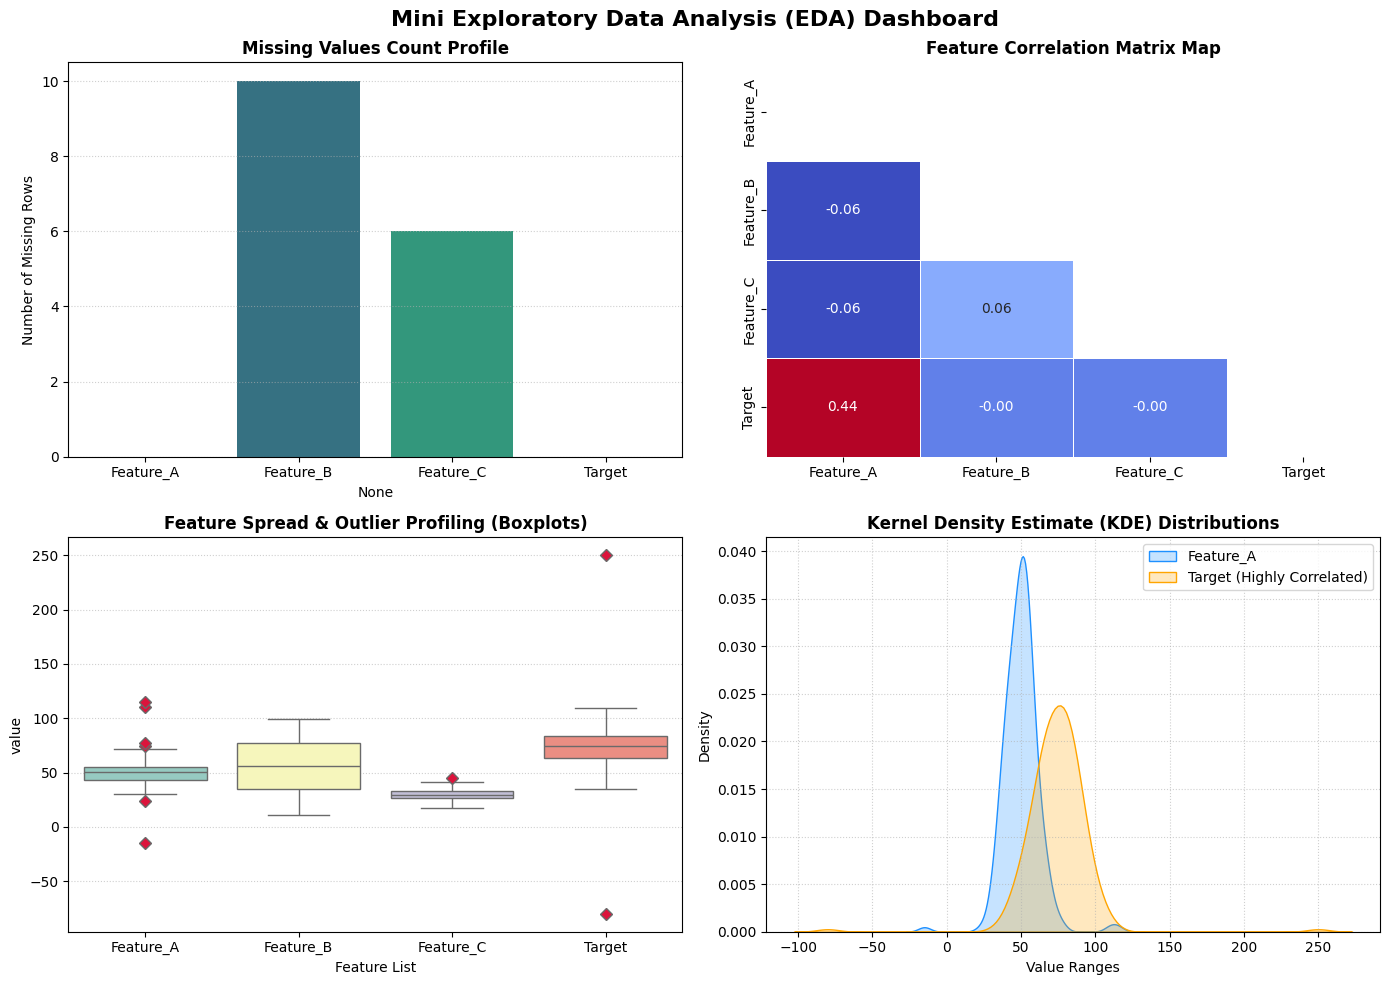

EDA Report processing successfully completed.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 200

data = {
    'Feature_A': np.random.normal(loc=50, scale=10, size=n_samples),
    'Feature_B': np.random.uniform(low=10, high=100, size=n_samples),
    'Feature_C': np.random.normal(loc=30, scale=5, size=n_samples),
    'Target': np.zeros(n_samples)
}
df = pd.DataFrame(data)

df['Target'] = df['Feature_A'] * 1.5 + np.random.normal(0, 5, n_samples)


df.loc[df.sample(frac=0.05).index, 'Feature_B'] = np.nan
df.loc[df.sample(frac=0.03).index, 'Feature_C'] = np.nan

df.loc[[15, 42, 103], 'Feature_A'] = [110, 115, -15]
df.loc[[77, 145], 'Target'] = [250, -80]

print("=" * 60)
print(" STARTING MINI EDA REPORT EXECUTION ")
print("=" * 60 + "\n")

print("MISSING VALUES ANALYSIS")
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing_Count': null_counts, 'Percentage_%': null_percentages})
print(missing_report.round(2).to_string())
print("\n" + "-" * 50 + "\n")

print(" CORRELATION ANALYSIS")
corr_matrix = df.corr()
print("Correlation Matrix Coefficients (Pearson):")
print(corr_matrix.round(2).to_string())
print("\n" + "-" * 50 + "\n")

print("[3/4] OUTLIER DETECTION (IQR METHOD)")
outlier_summary = {}

for col in df.select_dtypes(include=[np.number]).columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)
    print(f"Column '{col}': Bounds [{lower_bound:.1f} to {upper_bound:.1f}] -> Outliers Found: {len(outliers)}")

print("\n" + "-" * 50 + "\n")

print("GENERATING EDA VISUAL VISUALIZATION DASHBOARD")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Mini Exploratory Data Analysis (EDA) Dashboard", fontsize=16, fontweight='bold')

sns.barplot(x=missing_report.index, y=missing_report['Missing_Count'], ax=axes[0,0], palette='viridis')
axes[0,0].set_title("Missing Values Count Profile", fontweight='bold')
axes[0,0].set_ylabel("Number of Missing Rows")
axes[0,0].grid(axis='y', linestyle=':', alpha=0.6)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", mask=mask, ax=axes[0,1], cbar=False, linewidths=0.5)
axes[0,1].set_title("Feature Correlation Matrix Map", fontweight='bold')

df_melted = df.melt(value_vars=['Feature_A', 'Feature_B', 'Feature_C', 'Target'])
sns.boxplot(data=df_melted, x='variable', y='value', ax=axes[1,0], palette='Set3',
            flierprops={"markerfacecolor": "crimson", "marker": "D", "markersize": 6})
axes[1,0].set_title("Feature Spread & Outlier Profiling (Boxplots)", fontweight='bold')
axes[1,0].set_xlabel("Feature List")
axes[1,0].grid(axis='y', linestyle=':', alpha=0.6)

sns.kdeplot(data=df['Feature_A'], label='Feature_A', shade=True, ax=axes[1,1], color='dodgerblue')
sns.kdeplot(data=df['Target'], label='Target (Highly Correlated)', shade=True, ax=axes[1,1], color='orange')
axes[1,1].set_title("Kernel Density Estimate (KDE) Distributions", fontweight='bold')
axes[1,1].set_xlabel("Value Ranges")
axes[1,1].legend()
axes[1,1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("EDA Report processing successfully completed.")
